In [23]:
import os
import pickle
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, LayerNormalization,
    Concatenate, Lambda
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
from sklearn.model_selection import train_test_split


In [24]:
with open (r"D:\Uni\Year_3_sem_2\XAI\Project\phase_2\DeepSeps_final_processed_data\deepseps_train_data.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data)

<class 'dict'>
{'X_train': array([[[ 2.41506938e-01,  1.03184598e+00,  4.48169607e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01],
        [ 2.75983265e-01,  1.03184598e+00,  4.48169607e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01],
        [ 3.10459592e-01,  1.03184598e+00,  4.48169607e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01],
        ...,
        [ 9.65509810e-01,  1.03184598e+00,  2.14449678e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01],
        [ 9.99986138e-01,  1.03184598e+00,  2.14449678e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01],
        [ 1.03446246e+00,  1.03184598e+00,  2.14449678e-01, ...,
          5.82249791e-02,  2.08895239e+00, -1.61747209e-01]],

       [[-5.85924916e-01,  1.97732250e-01, -4.57495116e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        [-5.51448589e-01,  1.97732250e-01, -4.57495116e-01, ...,
          5

In [25]:
X_train = data["X_train"]
y_train = data["y_train"]

In [26]:
print(X_train.shape, y_train.shape)

(46106, 24, 24) (46106,)


In [27]:
with open (r"D:\Uni\Year_3_sem_2\XAI\Project\phase_2\DeepSeps_final_processed_data\deepseps_test_data.pkl", "rb") as f:
    data2 = pickle.load(f)

print(type(data2))
print(data2)

<class 'dict'>
{'X_test': array([[[ 1.38077956e-01,  5.87132948e-02, -7.93467513e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        [ 1.72554283e-01, -8.03056600e-02, -7.93467513e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        [ 2.07030611e-01, -8.03056600e-02, -7.93467513e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        ...,
        [ 8.62080829e-01, -4.97362524e-01, -7.64252522e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        [ 8.96557156e-01, -4.97362524e-01, -7.64252522e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01],
        [ 9.31033483e-01, -4.97362524e-01, -7.64252522e-01, ...,
          5.82249791e-02,  9.42105292e-02, -1.61747209e-01]],

       [[-1.03256335e-01,  2.81143623e-01,  1.35383433e+00, ...,
          5.82249791e-02, -9.03160400e-01, -1.61747209e-01],
        [-6.87800075e-02,  4.48113993e-02,  1.35383433e+00, ...,
          5.

In [28]:
X_test = data2["X_test"]
y_test = data2["y_test"]

In [29]:
print(X_test.shape, y_test.shape)

(6133, 24, 24) (6133,)


In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42
)

In [31]:
# Architecture:
#   1. Feature Embedding  — one FCN per vital sign (6 streams) + one shared FCN
#      for labs (15 features) + one for demographics (3 features).
#      Each FCN: Dense → LayerNormalization → Dropout.
#   2. Sequential Modeling — two stacked GRU layers.
#   3. Classifier — one FCN layer + sigmoid output.
#
# My data layout (24 features, 24 time-steps):
#   Vital signs  (6):  [1]Temp, [4]HR, [7]SBP, [9]MAP, [10]Resp, [12]DBP
#   Lab values  (15):  [2]WBC, [3]Platelets, [6]Glucose, [11]Creatinine,
#                      [13]BUN, [14]Hgb, [15]Calcium, [16]PTT, [17]Potassium,
#                      [18]Phosphate, [19]Magnesium, [20]PaCO2, [21]Chloride,
#                      [22]pH, [23]Lactate
#   Demographics (3):  [0]ICULOS, [5]Age, [8]HospAdmTime

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, LayerNormalization,
    Concatenate, Lambda
)

# Feature index mapping (matches your feature_names order)
VITAL_INDICES = [1, 4, 7, 9, 10, 12]          # 6 vital signs
LAB_INDICES   = [2, 3, 6, 11, 13, 14, 15,     # 15 lab values
                  16, 17, 18, 19, 20, 21, 22, 23]
DEMO_INDICES  = [0, 5, 8]                      # 3 demographic/temporal

N_VITALS  = len(VITAL_INDICES)   # 6
N_LABS    = len(LAB_INDICES)     # 15
N_DEMOS   = len(DEMO_INDICES)    # 3

FCN_UNITS    = 64
GRU_UNITS    = 64
DROPOUT_RATE = 0.3


def feature_fcn_block(x, units=FCN_UNITS, dropout_rate=DROPOUT_RATE, name_prefix=''):
    """FCN block: Dense → LayerNorm → Dropout (one per feature stream)."""
    x = Dense(units, activation='relu', name=f'{name_prefix}_dense')(x)
    x = LayerNormalization(name=f'{name_prefix}_ln')(x)
    x = Dropout(dropout_rate, name=f'{name_prefix}_drop')(x)
    return x


def build_deepseps_model(time_steps=24,
                          vital_indices=VITAL_INDICES,
                          lab_indices=LAB_INDICES,
                          demo_indices=DEMO_INDICES,
                          fcn_units=FCN_UNITS,
                          gru_units=GRU_UNITS,
                          dropout_rate=DROPOUT_RATE):

    n_features = len(vital_indices) + len(lab_indices) + len(demo_indices)
    inputs = Input(shape=(time_steps, n_features), name='input')

    # Feature Embedding
    # One separate FCN per vital sign
    vital_embeds = []
    for i, col in enumerate(vital_indices):
        pos = i
        vi = Lambda(lambda x, p=pos: x[:, :, p:p+1],
                    name=f'vital_slice_{i}')(inputs)
        vi = feature_fcn_block(vi, fcn_units, dropout_rate,
                                name_prefix=f'vital_{i}')
        vital_embeds.append(vi)


    n_v = len(vital_indices)
    n_l = len(lab_indices)
    lab_slice = Lambda(lambda x: x[:, :, n_v:n_v+n_l],
                       name='lab_slice')(inputs)
    lab_embed = feature_fcn_block(lab_slice, fcn_units, dropout_rate,
                                   name_prefix='labs')

    demo_slice = Lambda(lambda x: x[:, :, n_v+n_l:],
                        name='demo_slice')(inputs)
    demo_embed = feature_fcn_block(demo_slice, fcn_units, dropout_rate,
                                    name_prefix='demo')

    all_embeds = Concatenate(axis=-1, name='embed_concat')(
        vital_embeds + [lab_embed, demo_embed]
    )

    #  Sequential Characteristic Modeling
    x = GRU(gru_units, return_sequences=True, name='gru_1')(all_embeds)
    x = Dropout(dropout_rate, name='gru_1_drop')(x)
    x = GRU(gru_units, return_sequences=False, name='gru_2')(x)
    x = Dropout(dropout_rate, name='gru_2_drop')(x)

    # Classifier
    x = Dense(fcn_units, activation='relu', name='classifier_fcn')(x)
    x = Dropout(dropout_rate, name='classifier_drop')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, output, name='DeepSEPS')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model



# The model assumes inputs arrive in the order: vitals first, then labs, then demographics. 


In [32]:
class EpochTracker(Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath

    def on_epoch_end(self, epoch, logs=None):
        with open(self.filepath, "w") as f:
            f.write(str(epoch + 1))

In [33]:
RESUME_MODEL_PATH = "resume_model_final_run1.keras"
BEST_MODEL_PATH = "best_model_final_run1.keras"
EPOCH_FILE = "last_epoch_final_run1.txt"

In [34]:
# Reorder columns to match model input: [vitals | labs | demos]
col_order = VITAL_INDICES + LAB_INDICES + DEMO_INDICES
X_train = X_train[:, :, col_order]
X_val   = X_val[:, :, col_order]


model = build_deepseps_model(time_steps=X_train.shape[1])
initial_epoch = 0

model.summary()
print(f"Starting from epoch: {initial_epoch}")


Model: "DeepSEPS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 24, 24)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_0       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_1       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_2       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_3       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_4       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_slice_5       │ (None, 24, 1)     │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lab_slice (Lambda)  │ (None, 24, 15)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demo_slice (Lambda) │ (None, 24, 3)     │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_0_dense       │ (None, 24, 64)    │        128 │ vital_slice_0[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_1_dense       │ (None, 24, 64)    │        128 │ vital_slice_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_2_dense       │ (None, 24, 64)    │        128 │ vital_slice_2[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_3_dense       │ (None, 24, 64)    │        128 │ vital_slice_3[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_4_dense       │ (None, 24, 64)    │        128 │ vital_slice_4[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_5_dense       │ (None, 24, 64)    │        128 │ vital_slice_5[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ labs_dense (Dense)  │ (None, 24, 64)    │      1,024 │ lab_slice[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demo_dense (Dense)  │ (None, 24, 64)    │        256 │ demo_slice[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vital_0_ln          │ (None, 24, 64)    │        128 │ vital_0_dense[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 143,233 (559.50 KB)

 Trainable params: 143,233 (559.50 KB)

 Non-trainable params: 0 (0.00 B)

Starting from epoch: 0


In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'deepseps_best_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    initial_epoch=initial_epoch,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/50
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7823 - auc: 0.8667 - loss: 0.4425

649/649 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.8222 - auc: 0.9113 - loss: 0.3729 - val_accuracy: 0.8896 - val_auc: 0.9619 - val_loss: 0.2576
Epoch 2/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8806 - auc: 0.9555 - loss: 0.2693

649/649 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8910 - auc: 0.9614 - loss: 0.2518 - val_accuracy: 0.9154 - val_auc: 0.9766 - val_loss: 0.1983
Epoch 3/50
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9170 - auc: 0.9752 - loss: 0.2005

649/649 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.9220 - auc: 0.9774 - loss: 0.1910 - val_accuracy: 0.9234 - val_auc: 0.9826 - val_loss: 0.1878
Epoch 4/50
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9370 - auc: 0.9840 - loss: 0.1579

649/649 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9395 - auc: 0.9845 - loss: 0.1547 - val_accuracy: 0.9475 - val_auc: 0.9857 - val_loss: 0.1464
Epoch 5/50
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9504 - auc: 0.9889 - loss: 0.1292

649/649 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.9513 - auc: 0.9886 - loss: 0.1296 - val_accuracy: 0.9551 - val_auc: 0.9894 - val_loss: 0.1242
Epoch 6/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9544 - auc: 0.9901 - loss: 0.1204

649/649 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.9566 - auc: 0.9906 - loss: 0.1167 - val_accuracy: 0.9519 - val_auc: 0.9914 - val_loss: 0.1257
Epoch 7/50
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9636 - auc: 0.9930 - loss: 0.0991

649/649 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9650 - auc: 0.9932 - loss: 0.0969 - val_accuracy: 0.9573 - val_auc: 0.9915 - val_loss: 0.1111
Epoch 8/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9672 - auc: 0.9943 - loss: 0.0877

649/649 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9673 - auc: 0.9939 - loss: 0.0897 - val_accuracy: 0.9646 - val_auc: 0.9934 - val_loss: 0.1030
Epoch 9/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9722 - auc: 0.9950 - loss: 0.0789 - val_accuracy: 0.9612 - val_auc: 0.9920 - val_loss: 0.1188
Epoch 10/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9738 - auc: 0.9958 - loss: 0.0734 - val_accuracy: 0.9670 - val_auc: 0.9933 - val_loss: 0.0963
Epoch 11/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9777 - auc: 0.9966 - loss: 0.0648 - val_accuracy: 0.9703 - val_auc: 0.9933 - val_loss: 0.0951
Epoch 12/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9774 - auc: 0.9967 - loss: 0.0628 - val_accuracy: 0.9707 - val_auc: 0.9924 - val_loss: 0.0936
Epoch 13/50
649/649 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.9793 - auc: 0.9970 - loss: 0.0587 - val_accuracy: 0.9653 - val_auc: 0.9924 - val_loss: 0.1080
Epoch 13: early stopping
Restoring 

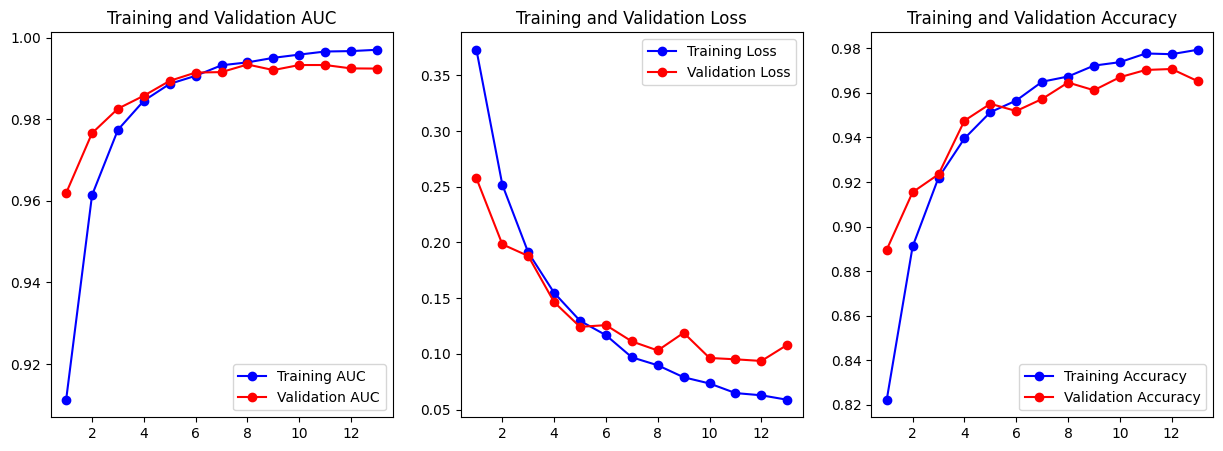

In [36]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Plot AUC
    plt.subplot(1, 3, 1)
    plt.plot(epochs, auc, 'bo-', label='Training AUC')
    plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

plot_learning_curves(history)

In [37]:
# 1. Get continuous probability scores (0 to 1)
y_probs = model.predict(X_test, verbose=0)

# 2. Convert probabilities to binary labels (0 or 1) using 0.5 threshold
y_pred = (y_probs > 0.5).astype(int)

print(f"Predictions completed for {len(y_test)} samples.")

Predictions completed for 6133 samples.


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f" DeepSeps Performance Summary")
print(f"Precision (Positive Predictive Value): {precision:.4f}")
print(f"Recall (Sensitivity):                {recall:.4f}")
print(f"F1 Score:                            {f1:.4f}")
print(f"ROC-AUC Score:                       {roc_auc:.4f}")
print(f"PR-AUC (Average Precision):          {pr_auc:.4f}")

 DeepSeps Performance Summary
Precision (Positive Predictive Value): 0.0945
Recall (Sensitivity):                0.4661
F1 Score:                            0.1571
ROC-AUC Score:                       0.6394
PR-AUC (Average Precision):          0.1138


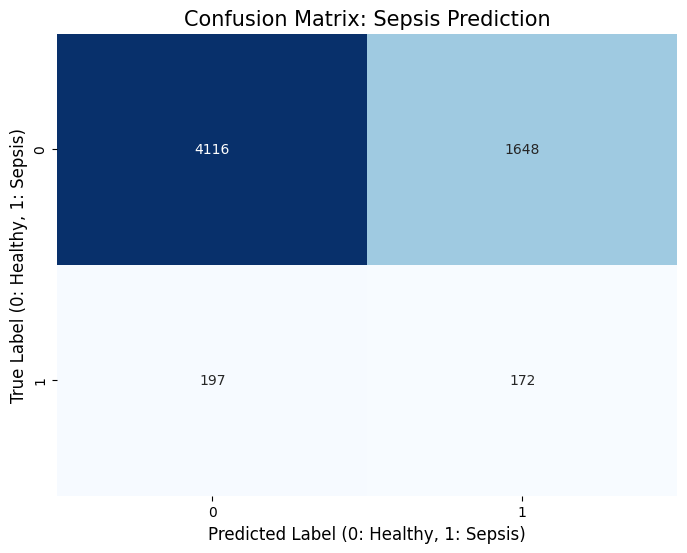

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Sepsis Prediction', fontsize=15)
plt.xlabel('Predicted Label (0: Healthy, 1: Sepsis)', fontsize=12)
plt.ylabel('True Label (0: Healthy, 1: Sepsis)', fontsize=12)
plt.show()

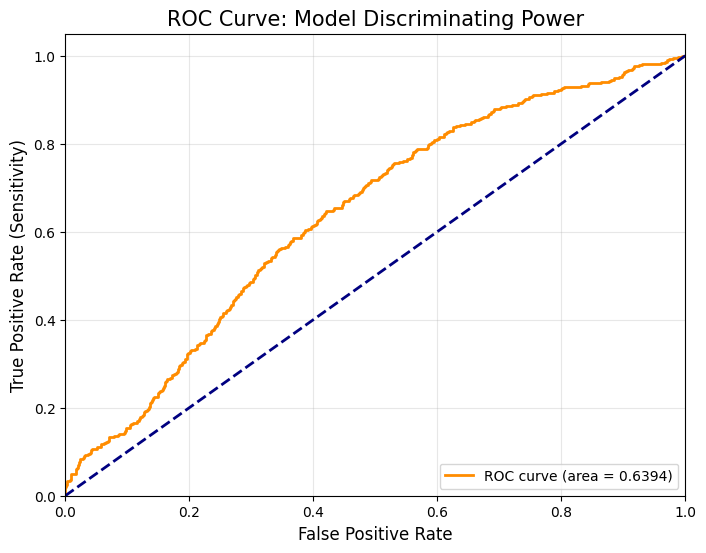

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve: Model Discriminating Power', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

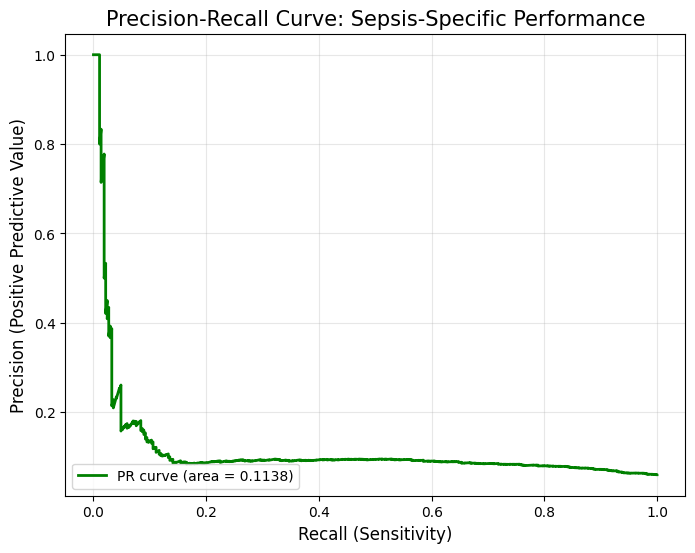

In [41]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='green', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve: Sepsis-Specific Performance', fontsize=15)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

SHAP for Time-Series 

SHAP explains the features. This will tell you if the sepsis prediction was driven by High Heart Rate, Low Blood Pressure, or Age.

C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(1, 24, 24))']
  warnings.warn(msg)
C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(50, 24, 24))']
  warnings.warn(msg)


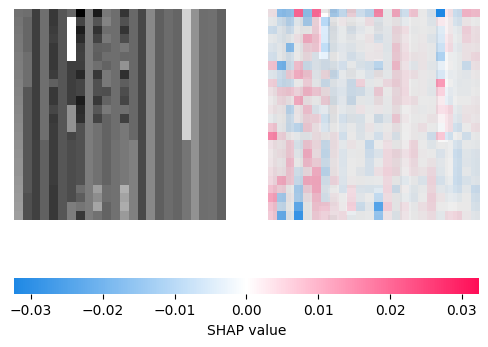

In [42]:
import shap

# Since Deep Learning models are complex, we use GradientExplainer or DeepExplainer
# We use a small subset of background data for speed
explainer = shap.GradientExplainer(model, X_train[:100])

# Explain a specific prediction from the test set
shap_values = explainer.shap_values(X_test[0:1])

# Visualize the feature importance for that patient
# Note: X_test[0] has shape (24, num_features)
shap.image_plot(shap_values, X_test[0:1])

In [43]:
features = data["feature_names"]

Calculating Permutation Importance (this may take a minute)...


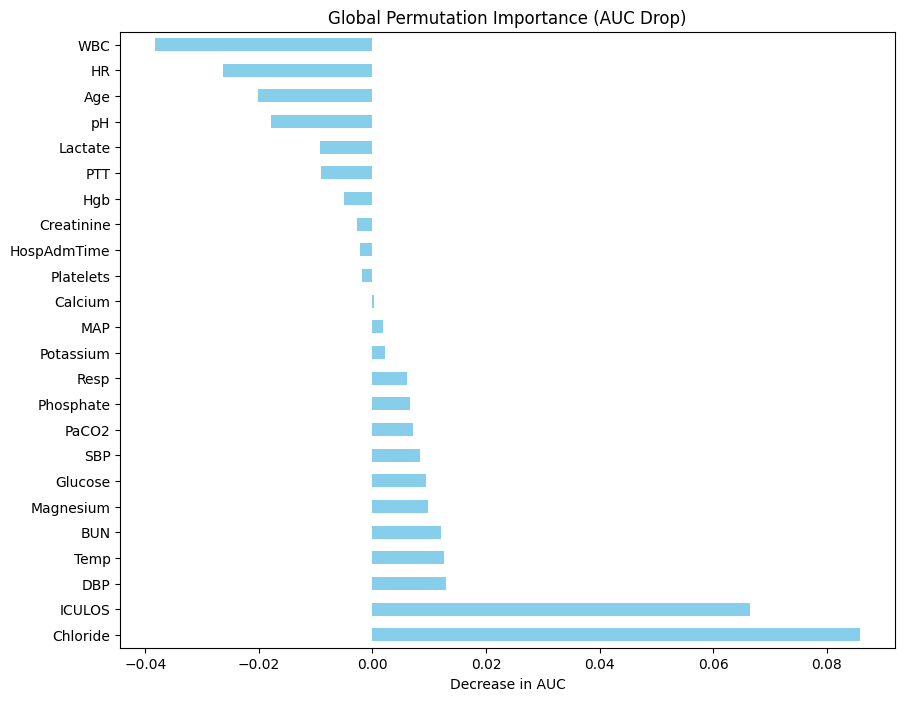

In [44]:
from sklearn.metrics import roc_auc_score
import pandas as pd

def calculate_permutation_importance(model, X, y, feature_names):
    # Get baseline AUC
    baseline_pred = model.predict(X, verbose=0)
    baseline_auc = roc_auc_score(y, baseline_pred)
    
    importances = {}
    
    print("Calculating Permutation Importance (this may take a minute)...")
    for i, name in enumerate(feature_names):
        X_permuted = X.copy()
        # Shuffle the feature across all patients and all time steps
        save_col = X_permuted[:, :, i].copy()
        flat_col = save_col.flatten()
        np.random.shuffle(flat_col)
        X_permuted[:, :, i] = flat_col.reshape(save_col.shape)
        
        # Measure performance drop
        perm_pred = model.predict(X_permuted, verbose=0)
        perm_auc = roc_auc_score(y, perm_pred)
        importances[name] = baseline_auc - perm_auc
        
    return pd.Series(importances).sort_values(ascending=False)

# Run and Plot
perm_imp = calculate_permutation_importance(model, X_test, y_test, features)
perm_imp.plot(kind='barh', color='skyblue', figsize=(10, 8))
plt.title("Global Permutation Importance (AUC Drop)")
plt.xlabel("Decrease in AUC")
plt.show()

In [45]:
features

['ICULOS',
 'Temp',
 'WBC',
 'Platelets',
 'HR',
 'Age',
 'Glucose',
 'SBP',
 'HospAdmTime',
 'MAP',
 'Resp',
 'Creatinine',
 'DBP',
 'BUN',
 'Hgb',
 'Calcium',
 'PTT',
 'Potassium',
 'Phosphate',
 'Magnesium',
 'PaCO2',
 'Chloride',
 'pH',
 'Lactate']

C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(1, 24, 24))']
  warnings.warn(msg)
C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(50, 24, 24))']
  warnings.warn(msg)


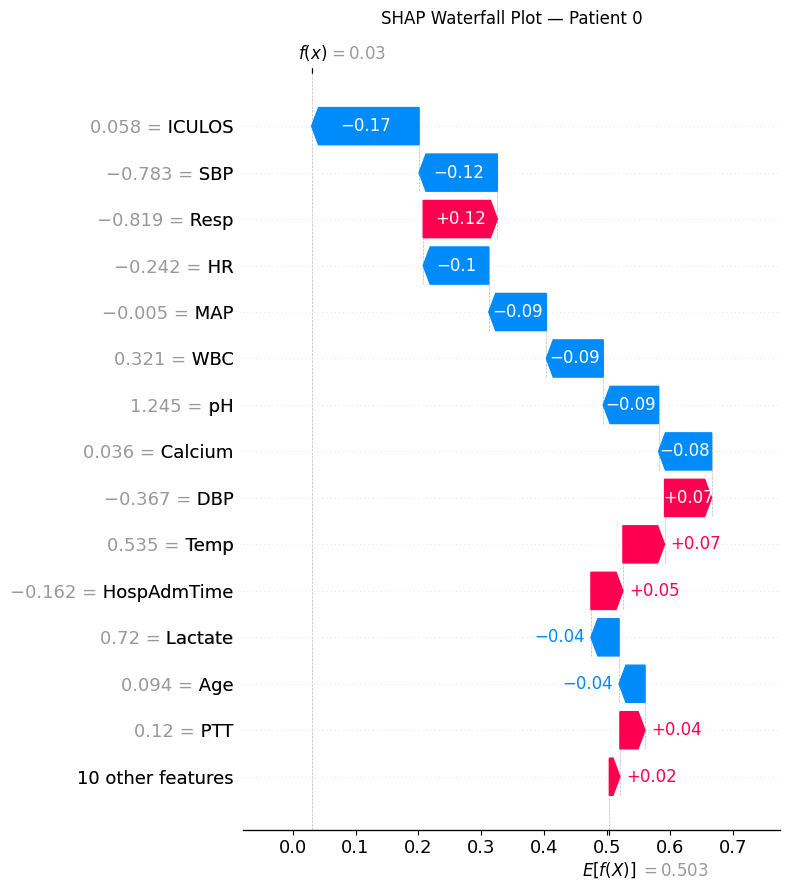

Saved: shap_waterfall.png  |  f(x) = 0.0303


In [46]:
explainer = shap.GradientExplainer(model, np.array(X_train[:100]))

patient_idx = 0
raw = explainer.shap_values(np.array(X_test[patient_idx : patient_idx + 1]))

sv_3d = raw[0] if isinstance(raw, list) else raw   # (1, T, F)

sv_time_abs  = np.abs(sv_3d[0]).sum(axis=0)
sv_time_sign = np.sign(sv_3d[0].mean(axis=0))
sv_per_feat  = sv_time_abs * sv_time_sign

data_per_feat = X_test[patient_idx].mean(axis=0)

sv_per_feat = sv_per_feat.squeeze()
data_per_feat = data_per_feat.squeeze()

col_order = VITAL_INDICES + LAB_INDICES + DEMO_INDICES
feature_names_ordered = [features[i] for i in col_order]

base_val = float(model.predict(np.array(X_train[:100]), verbose=0).mean())

explanation = shap.Explanation(
    values=sv_per_feat,
    base_values=base_val,
    data=data_per_feat,
    feature_names=feature_names_ordered
)

plt.figure()
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f"SHAP Waterfall Plot — Patient {patient_idx}", pad=14)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: shap_waterfall.png  |  f(x) = {base_val + sv_per_feat.sum():.4f}")

C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(200, 24, 24))']
  warnings.warn(msg)


ORIGINAL SV_BATCH: (200, 24, 24, 1)
SQUEEZED SV_BATCH: (200, 24, 24)
SHAP: (200, 24)
DATA: (200, 24)


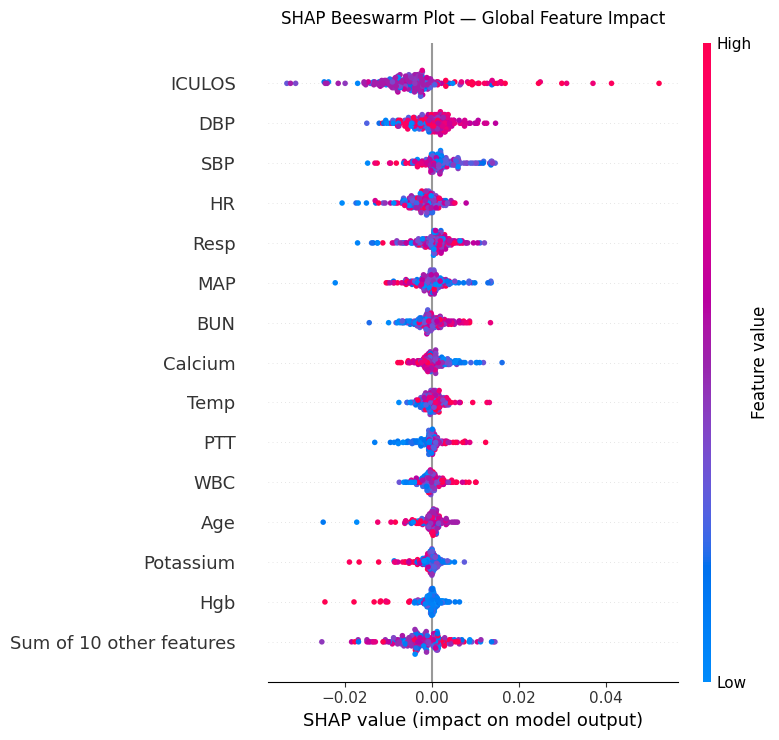

In [47]:
N_EXPLAIN = 200

shap_values_batch = explainer.shap_values(np.array(X_test[:N_EXPLAIN]))
sv_batch = shap_values_batch[0] if isinstance(shap_values_batch, list) else shap_values_batch

print("ORIGINAL SV_BATCH:", sv_batch.shape)

# REMOVE output dimension
sv_batch = sv_batch.squeeze(-1)   # (200, 24, 24)

print("SQUEEZED SV_BATCH:", sv_batch.shape)

# Collapse time
sv_2d = sv_batch.mean(axis=1)     # (200, 24)

# Data
X_test_2d = X_test[:N_EXPLAIN].mean(axis=1)

# Final check
print("SHAP:", sv_2d.shape)
print("DATA:", X_test_2d.shape)

expl_global = shap.Explanation(
    values=sv_2d,
    base_values=np.full(N_EXPLAIN, base_val),
    data=X_test_2d,
    feature_names=feature_names_ordered
)

plt.figure()
shap.plots.beeswarm(expl_global, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot — Global Feature Impact", pad=14)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

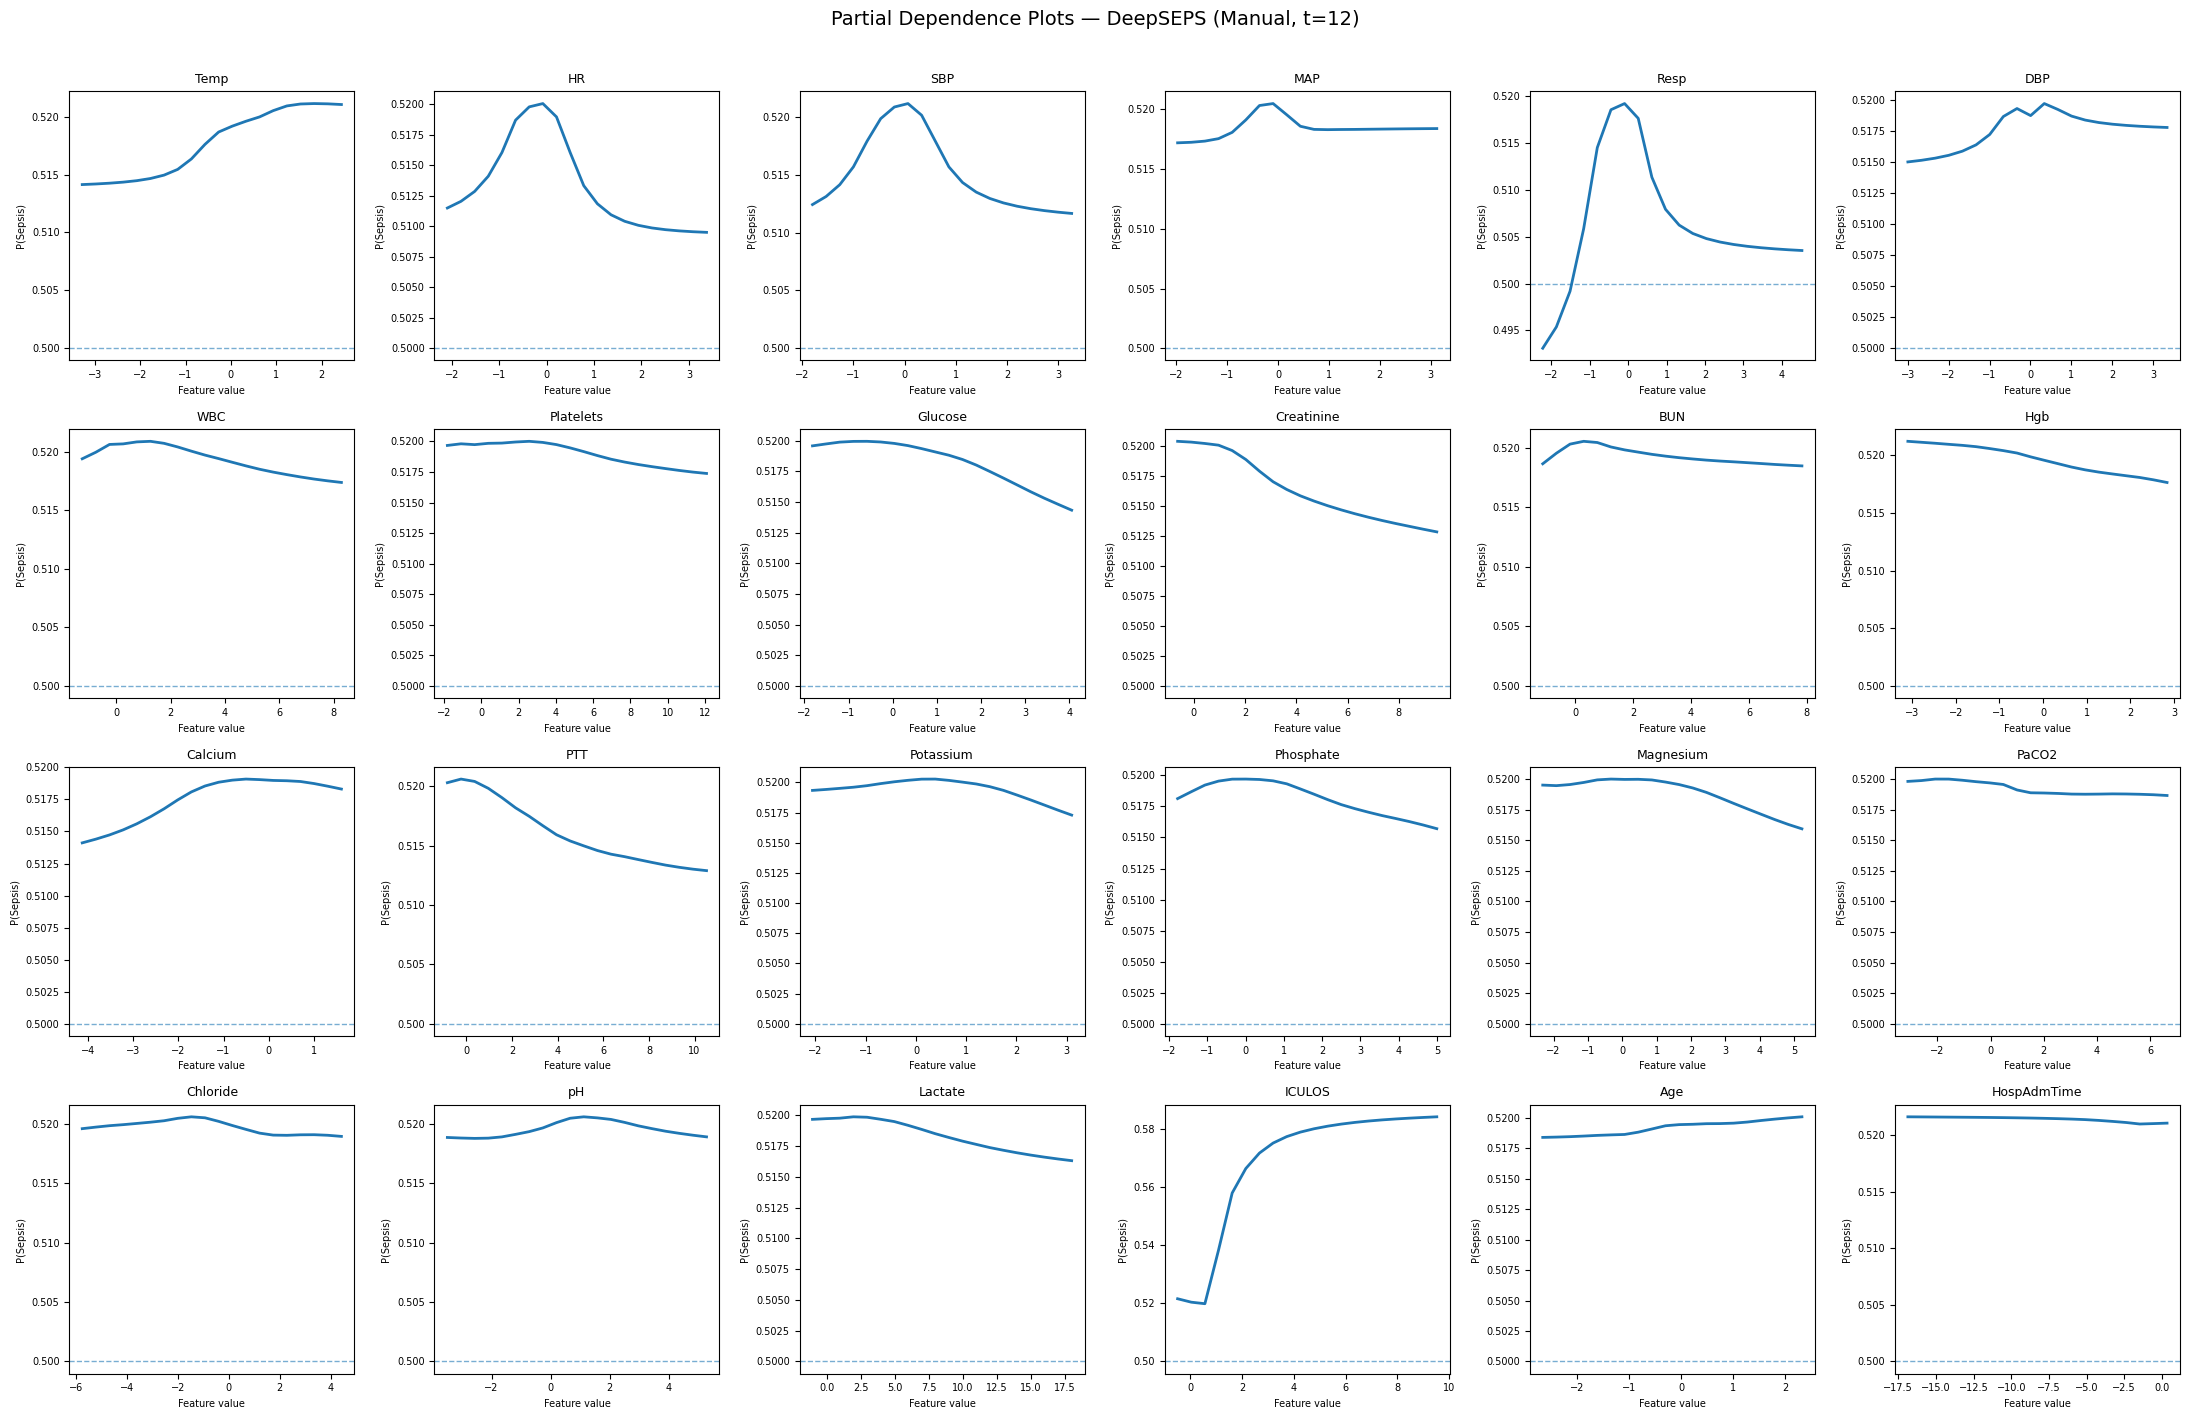

Saved: pdp_all_features.png


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
T, F = X_test.shape[1], X_test.shape[2]

X_test_flat  = X_test.reshape(len(X_test), -1)
X_train_flat = X_train.reshape(len(X_train), -1)

# Select timestep
MID_T = 12
selected_flat_idx = [MID_T * F + f for f in range(F)]
selected_names    = feature_names_ordered

# Background data
BG = X_train_flat[:300]

# Manual PDP function
def compute_pdp(model, X_flat, feature_idx, grid_resolution=20):
    """
    Compute PDP manually for one feature.
    """
    values = X_flat[:, feature_idx]
    grid = np.linspace(values.min(), values.max(), grid_resolution)

    pdp = []

    for val in grid:
        X_temp = X_flat.copy()
        X_temp[:, feature_idx] = val

        # reshape to 3D for Keras
        X_3d = X_temp.reshape(-1, T, F)

        preds = model.predict(X_3d, verbose=0).ravel()
        pdp.append(preds.mean())

    return grid, np.array(pdp)

# Plot PDPs
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.ravel()

for i, (feat_idx, name) in enumerate(zip(selected_flat_idx, selected_names)):
    grid_vals, avg_preds = compute_pdp(model, BG, feat_idx)

    ax = axes[i]
    ax.plot(grid_vals, avg_preds, lw=2)
    ax.axhline(0.5, linestyle="--", lw=1, alpha=0.6)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Feature value", fontsize=7)
    ax.set_ylabel("P(Sepsis)", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Partial Dependence Plots — DeepSEPS (Manual, t=12)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("pdp_all_features.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: pdp_all_features.png")

Computing H-statistics (manual)…
Chloride × ICULOS → H = 0.0252
Chloride × DBP → H = 0.0067
Chloride × Temp → H = 0.0041
Chloride × BUN → H = 0.0013
ICULOS × DBP → H = 0.0061
ICULOS × Temp → H = 0.0253
ICULOS × BUN → H = 0.0120
DBP × Temp → H = 0.0024
DBP × BUN → H = 0.0035
Temp × BUN → H = 0.0024


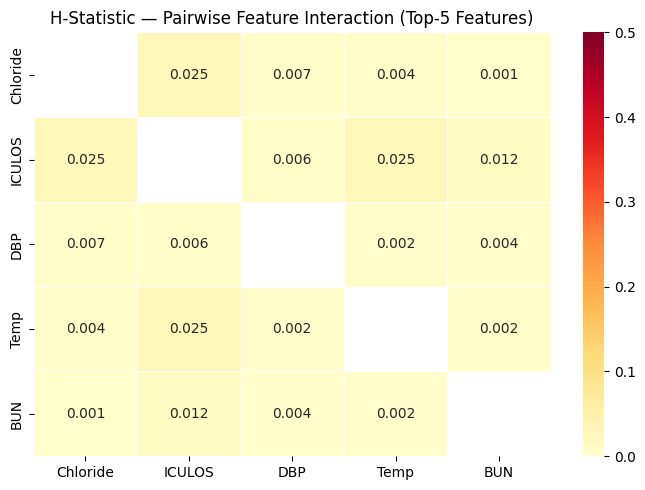

Saved: h_statistic_heatmap.png


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

T, F = X_test.shape[1], X_test.shape[2]

# Top-5 features
top5_names = perm_imp.head(5).index.tolist()
top5_idx   = [feature_names_ordered.index(n) for n in top5_names]
top5_flat  = [MID_T * F + f for f in top5_idx]

BG = X_train.reshape(len(X_train), -1)[:200]
GRID = 15

# Manual PDP (1 feature)
def pdp_1d(model, X_flat, feat_idx, grid_res):
    vals = X_flat[:, feat_idx]
    grid = np.linspace(vals.min(), vals.max(), grid_res)

    pdp = []
    for v in grid:
        X_temp = X_flat.copy()
        X_temp[:, feat_idx] = v
        X_3d = X_temp.reshape(-1, T, F)
        preds = model.predict(X_3d, verbose=0).ravel()
        pdp.append(preds.mean())

    return grid, np.array(pdp)

# Manual PDP (2 features)
def pdp_2d(model, X_flat, i, j, grid_res):
    vals_i = X_flat[:, i]
    vals_j = X_flat[:, j]

    grid_i = np.linspace(vals_i.min(), vals_i.max(), grid_res)
    grid_j = np.linspace(vals_j.min(), vals_j.max(), grid_res)

    pdp = np.zeros((grid_res, grid_res))

    for a, vi in enumerate(grid_i):
        for b, vj in enumerate(grid_j):
            X_temp = X_flat.copy()
            X_temp[:, i] = vi
            X_temp[:, j] = vj

            X_3d = X_temp.reshape(-1, T, F)
            preds = model.predict(X_3d, verbose=0).ravel()
            pdp[a, b] = preds.mean()

    return grid_i, grid_j, pdp

# H-statistic
def h_stat_pair_manual(model, X_flat, i, j, grid_res=GRID):
    _, _, pd_ij = pdp_2d(model, X_flat, i, j, grid_res)
    _, pd_i = pdp_1d(model, X_flat, i, grid_res)
    _, pd_j = pdp_1d(model, X_flat, j, grid_res)

    mean_pred = model.predict(X_flat.reshape(-1, T, F), verbose=0).mean()

    interaction = (
        pd_ij
        - pd_i[:, None]
        - pd_j[None, :]
        + mean_pred
    )

    num = (interaction ** 2).mean()
    den = (pd_ij ** 2).mean() + 1e-10

    return float(np.sqrt(num / den))


# Compute matrix
n = len(top5_names)
H = np.zeros((n, n))

print("Computing H-statistics (manual)…")

for a in range(n):
    for b in range(a + 1, n):
        h = h_stat_pair_manual(model, BG, top5_flat[a], top5_flat[b])
        H[a, b] = h
        H[b, a] = h
        print(f"{top5_names[a]} × {top5_names[b]} → H = {h:.4f}")

# Plot
mask = np.eye(n, dtype=bool)

plt.figure(figsize=(7, 5))
sns.heatmap(
    H,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=top5_names,
    yticklabels=top5_names,
    vmin=0,
    vmax=0.5,
    linewidths=0.5
)

plt.title("H-Statistic — Pairwise Feature Interaction (Top-5 Features)")
plt.tight_layout()
plt.savefig("h_statistic_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: h_statistic_heatmap.png")

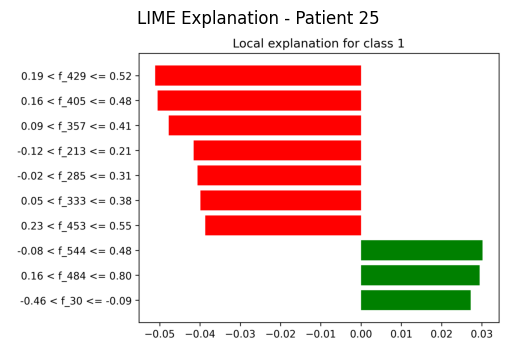

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt

# Define shape
T, F = X_train.shape[1], X_train.shape[2]

# Flatten training data (same as before)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Create explainer
explainer = LimeTabularExplainer(
    training_data=X_train_flat,
    mode='classification',
    feature_names=[f"f_{i}" for i in range(X_train_flat.shape[1])],
    discretize_continuous=True
)

def predict_proba_fixed(x):
    x_3d = x.reshape(-1, T, F)
    probs = model.predict(x_3d, verbose=0)
    return np.hstack([1 - probs, probs])

patient_index = 25  

# Get that patient's data
sample = X_train[patient_index].reshape(1, -1)[0]

# Generate explanation
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=predict_proba_fixed,
    num_features=10
)


file_name = f"lime_patient_{patient_index}.png"
fig = exp.as_pyplot_figure()
fig.savefig(file_name, dpi=300, bbox_inches='tight')

#
plt.imshow(plt.imread(file_name))
plt.axis('off')
plt.title(f"LIME Explanation - Patient {patient_index}")
plt.show()